Task 1: Term Deposit Subscription Prediction (Bank Marketing)
Objective
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.
Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score
import shap
import warnings
warnings.filterwarnings('ignore')


In [25]:
df = pd.read_csv(r'C:\Users\saad\Desktop\bank-full.csv', sep=";")

In [26]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [27]:
df.shape  # Check total rows and columns 

(45211, 17)

In [28]:
df.describe()   #Statistical Analysis

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [30]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [31]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Binary Encoding with LabelEcoder

In [32]:
columns=['default', 'housing','loan', 'y']
for col in columns:
    df[col] = df[col].map({"yes" : 1, "no" : 0})

In [33]:
for col in columns:
    print(col)
    print(df[col].unique())

default
[0 1]
housing
[1 0]
loan
[0 1]
y
[0 1]


In [34]:
category_columns = ["job", "marital", "education", "contact", "month", "poutcome"]

df = pd.get_dummies(df, columns=category_columns, drop_first=True, dtype=int)

In [35]:
df.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
1,44,0,29,1,0,5,151,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
2,33,0,2,1,1,5,76,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
3,47,0,1506,1,0,5,92,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
4,33,0,1,0,0,5,198,1,-1,0,...,0,0,0,1,0,0,0,0,0,1


We prepared the dataset for modeling by encoding binary columns using label encoding and applying one-hot encoding to categorical features, resulting in a fully numeric dataset suitable for training ML models.

In [36]:
X = df.drop("y", axis=1)
y = df["y"]

In [37]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [38]:
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
y_pred = lr_model.predict(x_test)

In [40]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9043,))

In [41]:
cm = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix")
print(cm)
print("\n============================")
print("\n F1 Score")
print(f1)

Confusion Matrix
[[7797  188]
 [ 723  335]]


 F1 Score
0.42378241619228335


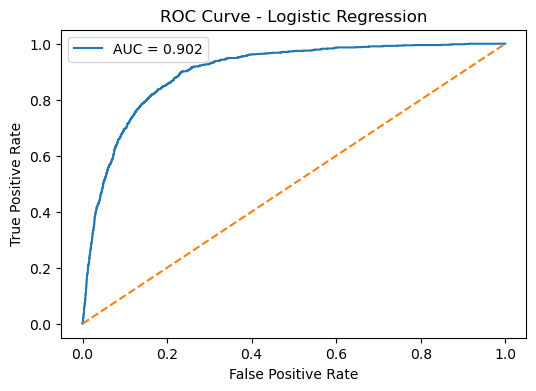

AUC Score: 0.9018109333071341


In [42]:
y_prob = lr_model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

In [43]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_pred_rf = rf_model.predict(x_test)

In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nF1 Score:")
print(f1_rf)

Confusion Matrix:
[[7777  208]
 [ 643  415]]

F1 Score:
0.49375371802498513


In [46]:
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC Score:", auc_rf)

AUC Score: 0.9280162000348007


In [47]:
X_sample = x_test.sample(100, random_state=42)

explainer = shap.Explainer(rf_model, X_sample)
shap_values = explainer(X_sample)


 99%|===================| 198/200 [00:16<00:00]        

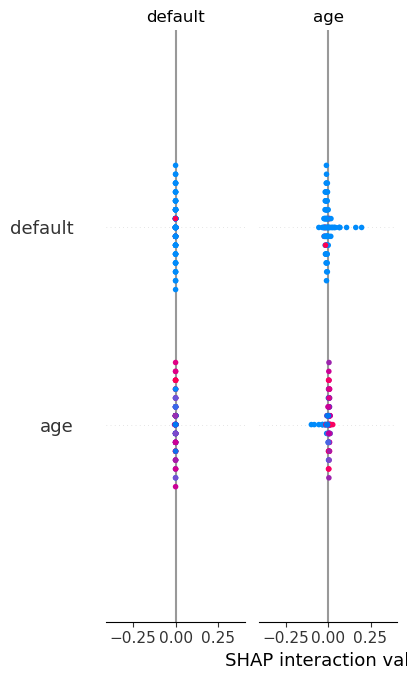

In [48]:
shap.summary_plot(shap_values, X_sample)

In [49]:
X_sample = x_test.sample(5, random_state=42)

explainer = shap.Explainer(rf_model, x_train)
shap_values = explainer(X_sample)

Background dataset has 36168 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=36168 when initializing the masker.


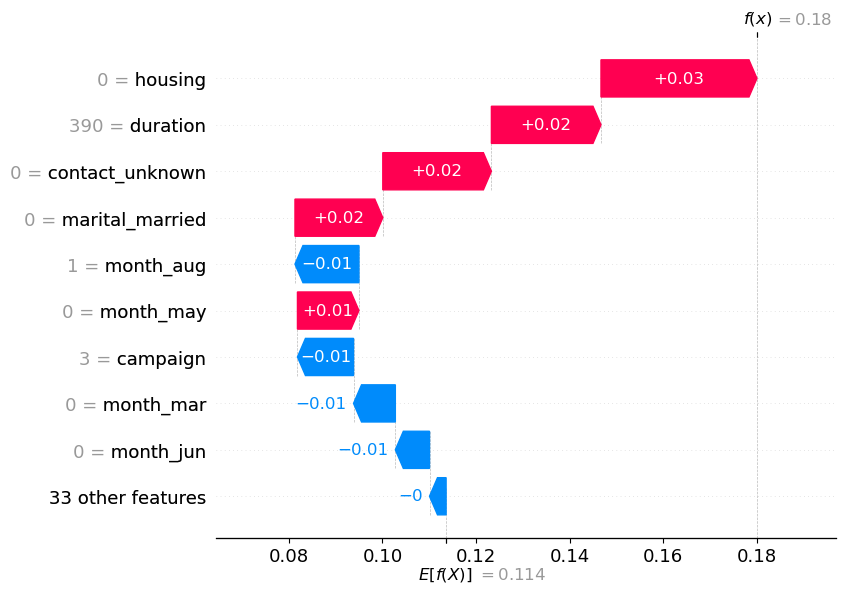

In [50]:
shap.plots.waterfall(shap_values[0, :, 1])

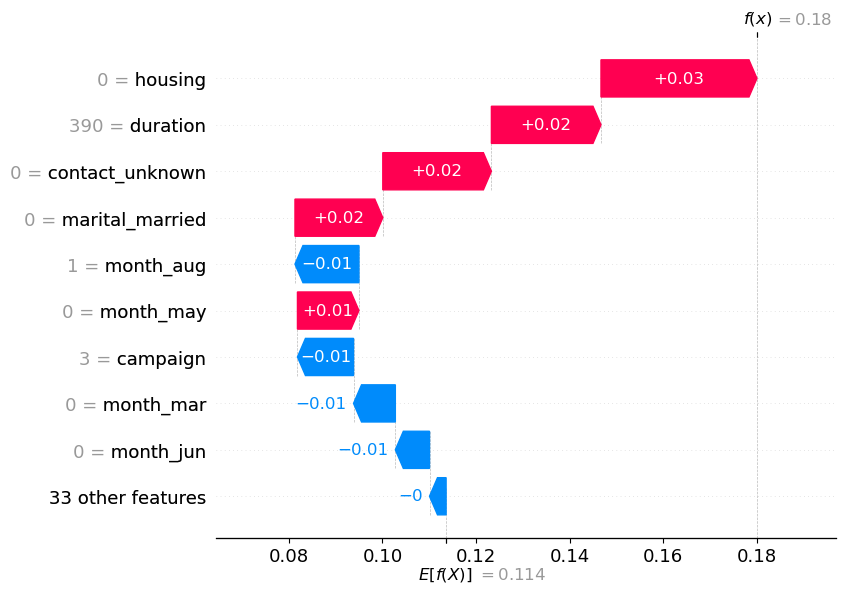

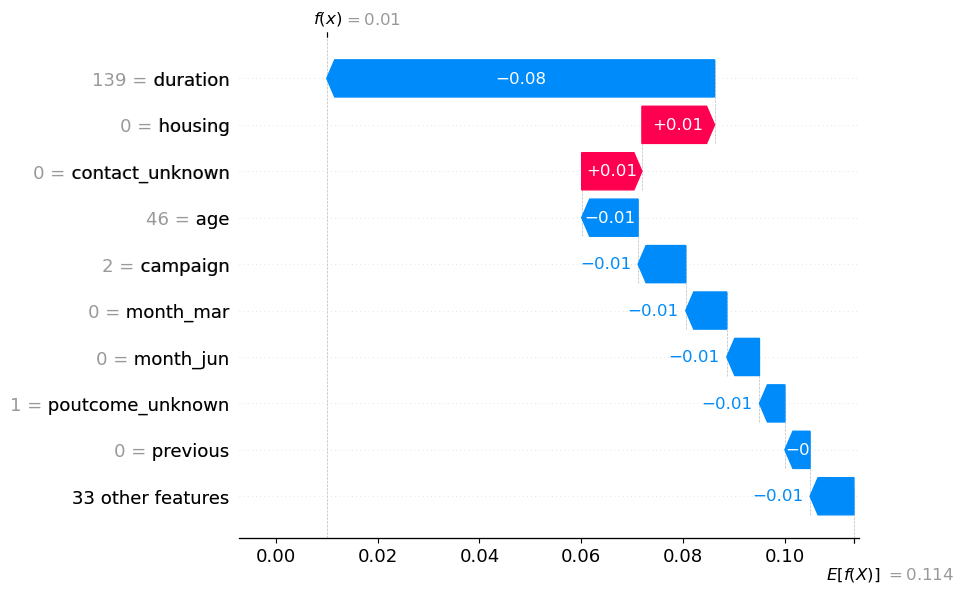

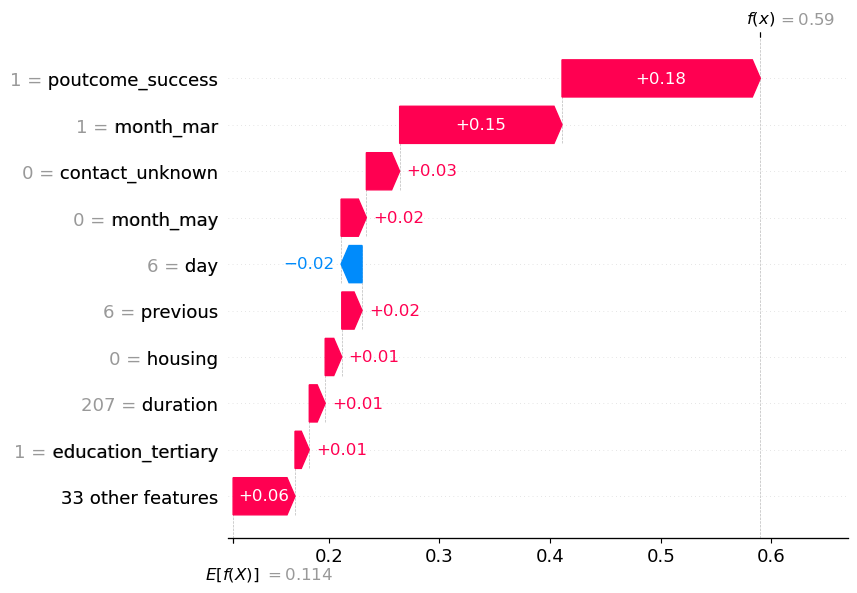

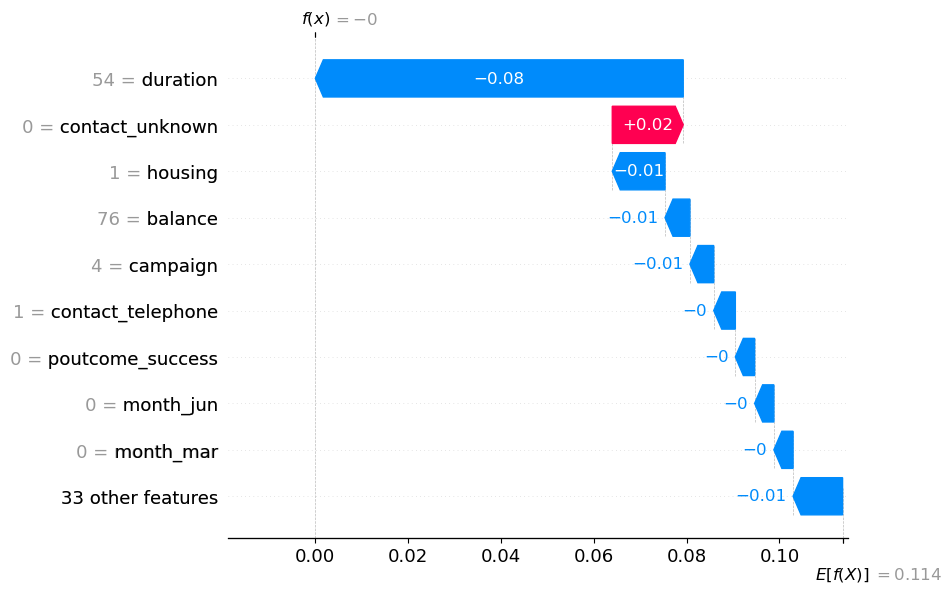

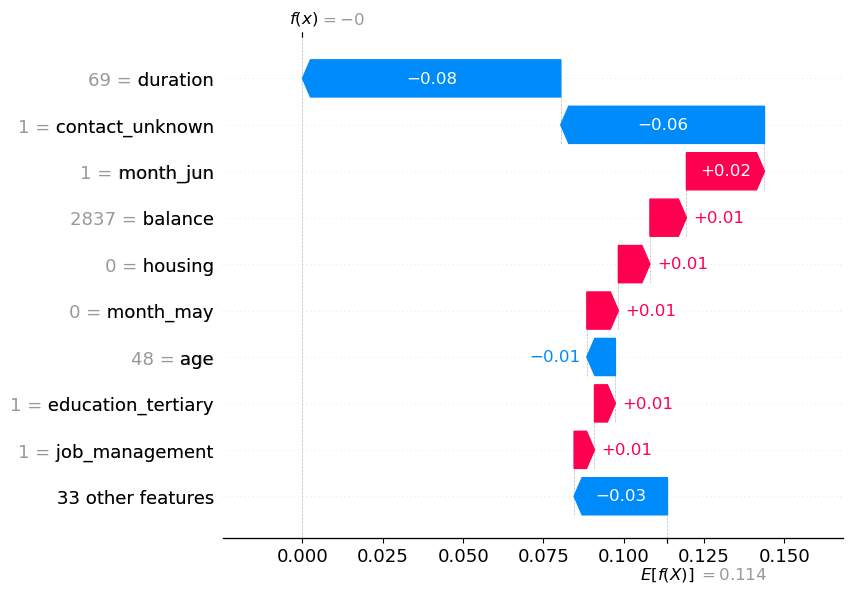

In [51]:
for i in range(5):
    shap.plots.waterfall(shap_values[i, :, 1])

The model predicted that this customer is likely to subscribe to a term deposit. The prediction was mainly influenced by longer call duration, positive previous campaign outcome, and higher account balance, which increased the probability. However, having a housing loan slightly reduced the final probability.

SHAP was used to explain individual predictions of the Random Forest model by showing how each feature affects the output. It identifies which features push the prediction toward “Yes” or “No”.

The analysis showed that features like call duration, account balance, and previous campaign outcome had the strongest impact on predictions. SHAP improved model interpretability by clearly explaining why each customer was predicted to subscribe or not.